In [2]:
# import libraries 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

In [3]:
# load dataset 
diabetes = load_diabetes()
X = diabetes.data[:, np.newaxis, 2] # using one feature for simplicity
y = diabetes.target

In [5]:
# split the dataset into training and testing sets
# traning data 80% and testing data 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# underfitting model 
model_underfit = make_pipeline(
    PolynomialFeatures(degree=1), # using linear regression (degree 1)
    LinearRegression()
)
model_underfit.fit(X_train, y_train)

# note if you want good fitting then you have to increase the degree of polynomial features mean 3 or 4 or 5 but it will lead to overfitting

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,1
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [8]:
# good fitting model
model_goodfit = make_pipeline(
    PolynomialFeatures(degree=3), # using polynomial regression (degree 3)
    LinearRegression()
)
model_goodfit.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,3
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [9]:
model_overfit = make_pipeline(
    PolynomialFeatures(degree=15), # using polynomial regression (degree 15)
    LinearRegression()
)
model_overfit.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,15
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [10]:
# Evaluate the models
print("Underfitting Train score:", model_underfit.score(X_train, y_train))
print("Underfitting Test score:", model_underfit.score(X_test, y_test))

print("Good fitting Train score:", model_goodfit.score(X_train, y_train))
print("Good fitting Test score:", model_goodfit.score(X_test, y_test))

print("Overfitting Train score:", model_overfit.score(X_train, y_train))
print("Overfitting Test score:", model_overfit.score(X_test, y_test))


Underfitting Train score: 0.3657241273794126
Underfitting Test score: 0.23335039815872138
Good fitting Train score: 0.36665649129084277
Good fitting Test score: 0.23285636640090268
Overfitting Train score: 0.38974989365642443
Overfitting Test score: -4.73621336954708


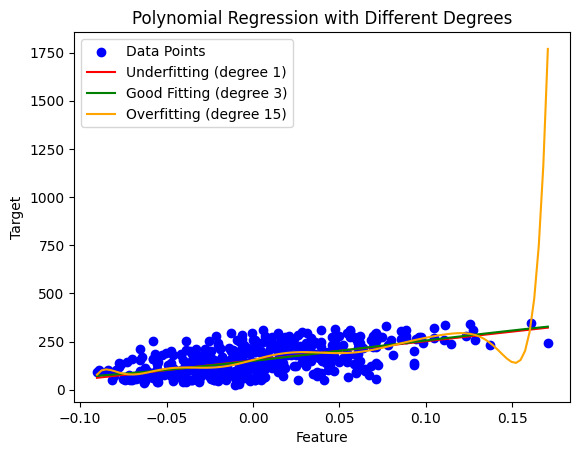

In [12]:
# simple visualization of underfitting, good fitting and overfitting models

X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

plt.scatter(X, y, color='blue', label='Data Points')

plt.plot(X_plot, model_underfit.predict(X_plot), color='red', label='Underfitting (degree 1)')
plt.plot(X_plot, model_goodfit.predict(X_plot), color='green', label='Good Fitting (degree 3)')
plt.plot(X_plot, model_overfit.predict(X_plot), color='orange', label='Overfitting (degree 15)')

plt.legend()
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Polynomial Regression with Different Degrees')
plt.show()